In [1]:
%load_ext autoreload
%autoreload 2
%env TORCH_COMPILE_DISABLE=1

env: TORCH_COMPILE_DISABLE=1


In [7]:
from brain_image.model.comm_alignment import CommAlignmentModel
from brain_image.model.prior import SimpleDiffusionPrior
from brain_image.utils import get_submodules_with_pattern
from brain_image.model.prior import DiffusionPriorConfig
from brain_image.data.data import get_from_batch

from pathlib import Path
import itertools as it
import numpy as np
from torch import Tensor
from torch.nn import functional as F
import tqdm
import pandas as pd
import torch

In [6]:
comm_cp = Path("checkpoints/train_comm-15445420-20260206_021738/version_0/checkpoints/epoch_0033-val_loss_17.7101.ckpt")
prior_cp = Path("checkpoints/train_eeg-15445445-20260206_025856/version_0/checkpoints/epoch_0484-val_loss_0.4309.ckpt")

comm = CommAlignmentModel.load_from_checkpoint(comm_cp)

state_dict = torch.load(prior_cp)
prior_config = state_dict["hyper_parameters"]["config"]["prior"]
prior_state_dict = get_submodules_with_pattern(state_dict["state_dict"], "prior")
prior = SimpleDiffusionPrior(
    DiffusionPriorConfig(**prior_config),
    embedding_stats=comm.data_module.get_embedding_stats()["align_img_latent"]
)
prior.load_state_dict(prior_state_dict)

Seed set to 42


<All keys matched successfully>

In [8]:
device = torch.device("cuda")
prior.eval()
prior.to(device)
comm.eval()
comm.to(device)

example_batch = next(iter(comm.data_module.get_dataloader("test")))
example_batch.keys()

dict_keys(['img_path', 'eeg_data', 'idx', 'sub', 'align_img_latent'])

In [ ]:

values = []

ns = list(np.linspace(0, 30, 20).astype(int))
gs = list(np.linspace(0, 4, 20))
params = list(it.product(ns, gs))

for n, g in tqdm.tqdm(params):
    with torch.no_grad():
        target = get_from_batch("align_img_latent", example_batch, Tensor).to(device)
        eeg = get_from_batch("eeg_data", example_batch, Tensor).to(device)
        eeg_latent = F.normalize(comm.eeg_encoder(eeg), dim=-1)
        clip_pred = prior.generate(conditioning=eeg_latent, guidance_scale=g, num_steps=n)
        mean_sim = round(F.cosine_similarity(target, clip_pred, dim=-1).mean().item(), 5)
        std_sim = round(F.cosine_similarity(target, clip_pred, dim=-1).std().item(), 5)
        
        values.append((n, g, mean_sim, std_sim))


df = pd.DataFrame(values, columns=["n", "g", "mean_sim", "std_sim"])
df = df.sort_values("mean_sim", ascending=False)
df

  0%|          | 0/400 [00:00<?, ?it/s]/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/diffusers/schedulers/scheduling_ddpm.py:307: RuntimeWarning: divide by zero encountered in scalar floor_divide
  step_ratio = self.config.num_train_timesteps // self.num_inference_steps
100%|██████████| 400/400 [00:33<00:00, 11.78it/s]


,n,g,mean_sim,std_sim
65,4,1.052632,0.76876,0.07987
106,7,1.263158,0.76847,0.07748
110,7,2.105263,0.76841,0.08012
67,4,1.473684,0.76770,0.08357
86,6,1.263158,0.76735,0.07939
...,...,...,...,...
8,0,1.684211,0.49638,0.05855
6,0,1.263158,0.49628,0.05831
13,0,2.736842,0.49540,0.05902
4,0,0.842105,0.49484,0.06149


In [9]:
#torch.manual_seed(42)
from brain_image.metrics import get_retrieval_accuracy

with torch.no_grad():
    target = get_from_batch("align_img_latent", example_batch, Tensor).to(device)
    eeg = get_from_batch("eeg_data", example_batch, Tensor).to(device)
    eeg_latent = comm.eeg_encoder(eeg)
    eeg_latent_normed = F.normalize(eeg_latent, dim=-1)
    clip_pred = prior.generate(conditioning=eeg_latent_normed, guidance_scale=1.0, num_steps=15, unscale=True)

    print(clip_pred.mean(dim=0).mean(), clip_pred.std(dim=0).mean(), target.mean(dim=0).mean(), target.std(dim=0).mean())
    print(clip_pred.norm(dim=-1).mean(), target.norm(dim=-1).mean())
    print(F.cosine_similarity(target, clip_pred, dim=-1).mean())

    z_proto_gt = comm.comm.encode_feature([eeg_latent, target], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)
    z_proto_pred = comm.comm.encode_feature([eeg_latent, clip_pred], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)
    z_img_target = comm.comm.encode_feature([target], comm.config.img_idx, skip_encoder=True)

    acc_proto_to_img, acc_img_to_proto = get_retrieval_accuracy(z_proto_pred, z_img_target, norm=True)
    acc_proto_to_img_target, acc_img_to_proto_target = get_retrieval_accuracy(z_proto_gt, z_img_target, norm=True)
    print(f"acc_proto_to_img: {acc_proto_to_img}")
    print(f"acc_img_to_proto: {acc_img_to_proto}")

    print(f"acc_proto_to_img_target: {acc_proto_to_img_target}")
    print(f"acc_img_to_proto_target: {acc_img_to_proto_target}")

    print(F.cosine_similarity(z_proto_pred, z_proto_gt, dim=-1).mean().item())

tensor(-0.0576, device='cuda:0') tensor(0.1281, device='cuda:0') tensor(-0.0571, device='cuda:0') tensor(0.3318, device='cuda:0')
tensor(10.2314, device='cuda:0') tensor(13.3354, device='cuda:0')
tensor(0.7573, device='cuda:0')
acc_proto_to_img: 0.32499998807907104
acc_img_to_proto: 0.3999999761581421
acc_proto_to_img_target: 0.8849999904632568
acc_img_to_proto_target: 0.98499995470047
0.8217841386795044


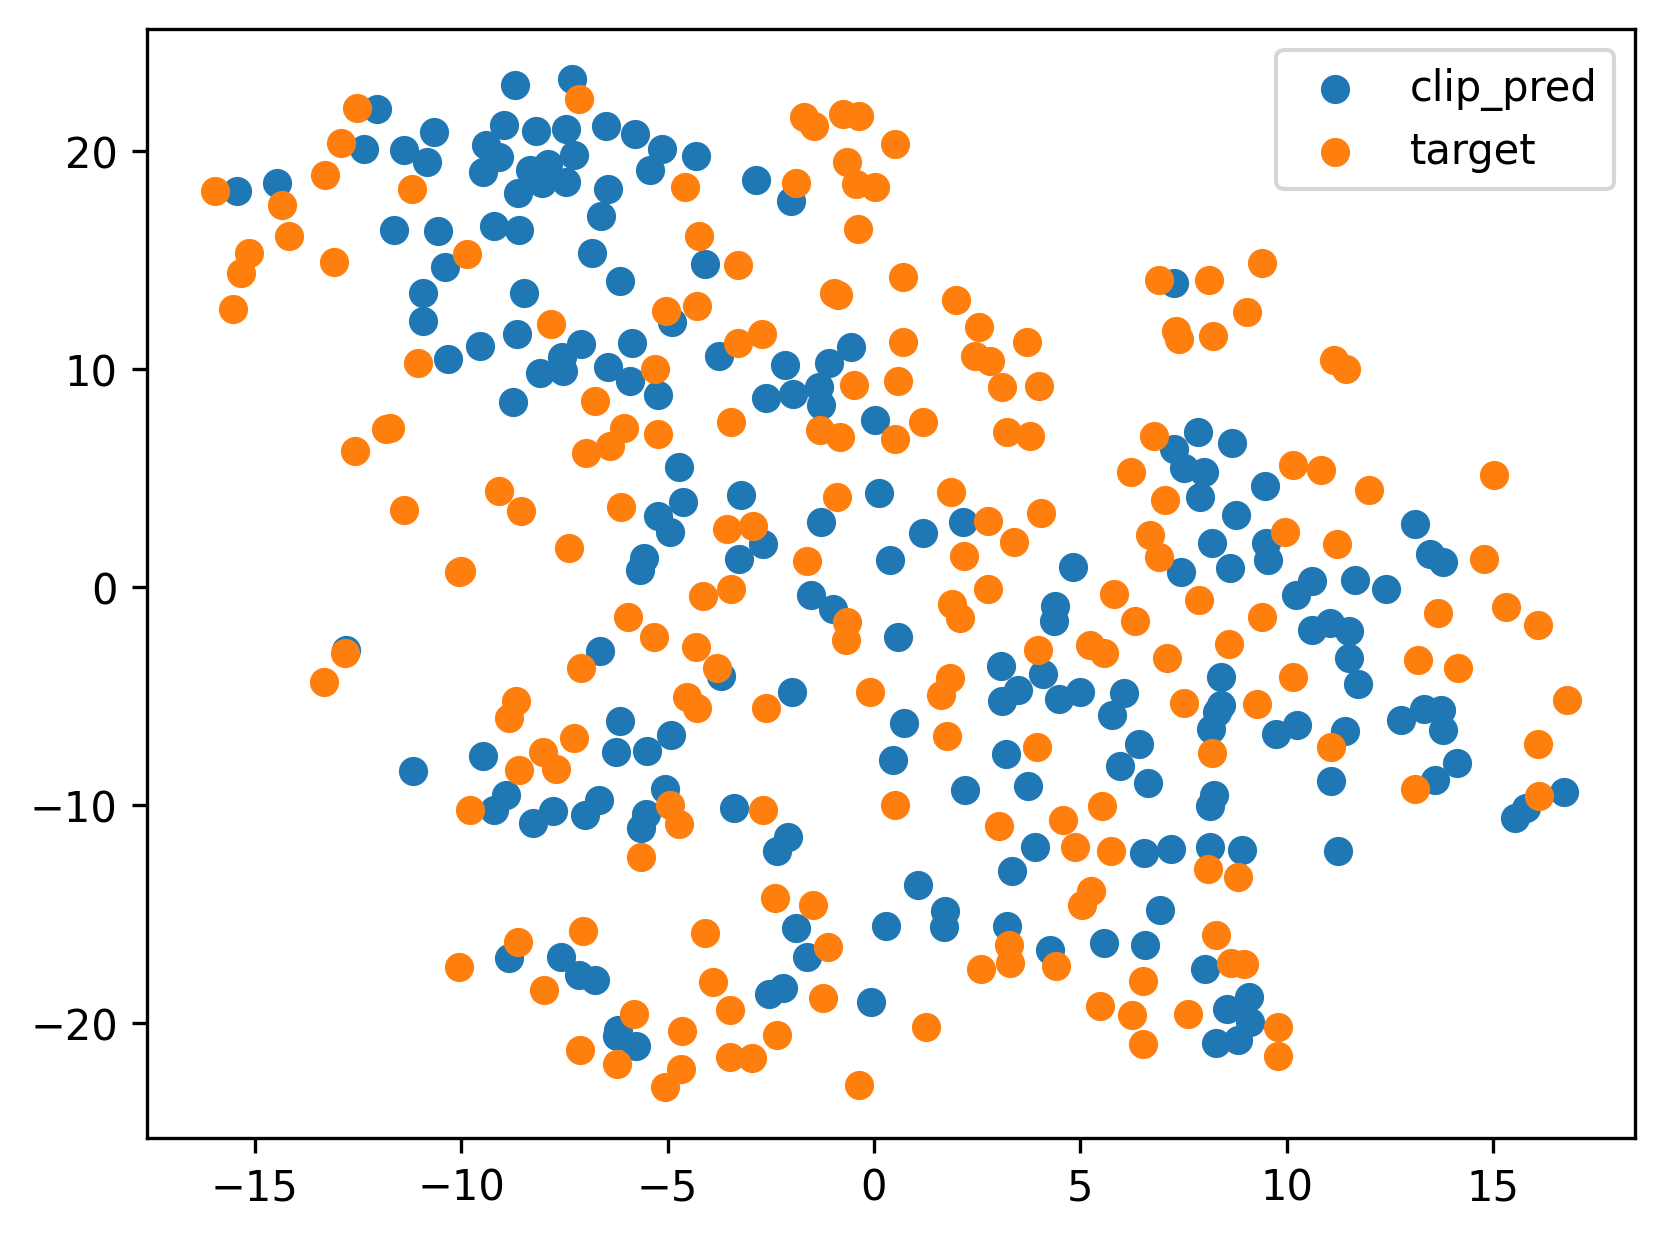

In [ ]:
from brain_image.stats import plot_projected_latents

plot_projected_latents([clip_pred, target], ["clip_pred", "target"])